In [1]:
!pip install focal-loss

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 5.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

2025-12-30 11:36:04.320893: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767094564.531983      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767094564.590776      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
SEED = 24520152

In [4]:
tf.keras.utils.set_random_seed(SEED)

In [5]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [6]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [7]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [8]:
MODEL1_DIR = '/kaggle/input/densenet121-ensemble/DenseNet121_Ensemble'
MODEL1_DIR

'/kaggle/input/densenet121-ensemble/DenseNet121_Ensemble'

In [9]:
preprocess_fn1 = applications.densenet.preprocess_input

In [10]:
MODEL2_DIR = '/kaggle/input/resnet50-ensemble/ResNet50_Ensemble'
MODEL2_DIR

'/kaggle/input/resnet50-ensemble/ResNet50_Ensemble'

In [11]:
preprocess_fn2 = applications.resnet.preprocess_input

In [12]:
MODEL3_DIR = '/kaggle/input/xception-ensemble/Xception_Ensemble'
MODEL3_DIR

'/kaggle/input/xception-ensemble/Xception_Ensemble'

In [13]:
preprocess_fn3 = applications.xception.preprocess_input

In [14]:
def get_validation_fold(k, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    AUTOTUNE = tf.data.AUTOTUNE

    return val_ds

In [15]:
def test(val_ds, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    model1 = tf.keras.models.load_model(os.path.join(MODEL1_DIR, f'DenseNet121_block_2_fold_{fold_k}.keras'))
    model2 = tf.keras.models.load_model(os.path.join(MODEL2_DIR, f'ResNet50_block_1_fold_{fold_k}.keras'))
    model3 = tf.keras.models.load_model(os.path.join(MODEL3_DIR, f'Xception_block_2_fold_{fold_k}.keras'))

    AUTOTUNE = tf.data.AUTOTUNE
    val_ds1 = val_ds.map(lambda image, label: (preprocess_fn1(image), label)).prefetch(buffer_size=AUTOTUNE)
    val_ds2 = val_ds.map(lambda image, label: (preprocess_fn2(image), label)).prefetch(buffer_size=AUTOTUNE)
    val_ds3 = val_ds.map(lambda image, label: (preprocess_fn3(image), label)).prefetch(buffer_size=AUTOTUNE)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    pred1 = model1.predict(val_ds1)
    pred2 = model2.predict(val_ds2)
    pred3 = model3.predict(val_ds3)
    ensemble_pred = (pred1 + pred2 + pred3) / 3.0
    y_pred = np.argmax(ensemble_pred, axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — Ensemble DenseNet121 - ResNet50 - Xception')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    acc = accuracy_score(y_true, y_pred)

    del model1, model2, model3, val_ds1, val_ds2, val_ds3, y_true, pred1, pred2, pred3, ensemble_pred, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [16]:
acc = []

Fold: 1
Found 542 files belonging to 3 classes.


I0000 00:00:1767094579.843492      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1767094598.901060     118 service.cc:148] XLA service 0x7f48d00025b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767094598.901869     118 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767094600.205659     118 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/17 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

I0000 00:00:1767094609.631558     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 909ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 343ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 359ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.99      0.99       245
Meningioma Tumor       0.98      0.95      0.96       112
 Pituitary Tumor       0.98      1.00      0.99       185

        accuracy                           0.98       542
       macro avg       0.98      0.98      0.98       542
    weighted avg       0.98      0.98      0.98       542



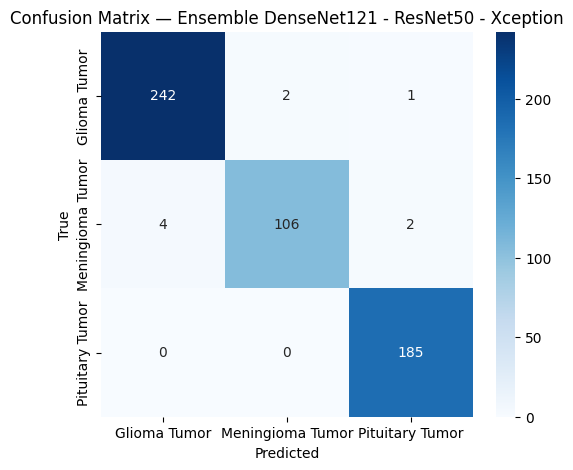

Fold: 2
Found 679 files belonging to 3 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 645ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.94      0.93       338
Meningioma Tumor       0.88      0.79      0.83       167
 Pituitary Tumor       0.92      0.96      0.94       174

        accuracy                           0.91       679
       macro avg       0.90      0.90      0.90       679
    weighted avg       0.91      0.91      0.91       679



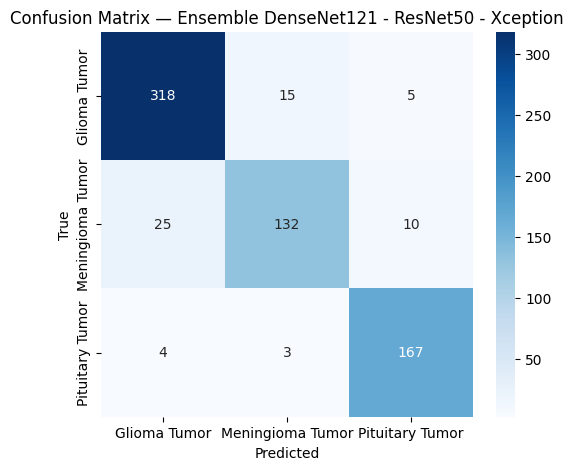

Fold: 3
Found 572 files belonging to 3 classes.
18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 834ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 328ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 394ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.90      0.92       231
Meningioma Tumor       0.83      0.87      0.85       139
 Pituitary Tumor       0.97      1.00      0.98       202

        accuracy                           0.92       572
       macro avg       0.92      0.92      0.92       572
    weighted avg       0.93      0.92      0.92       572



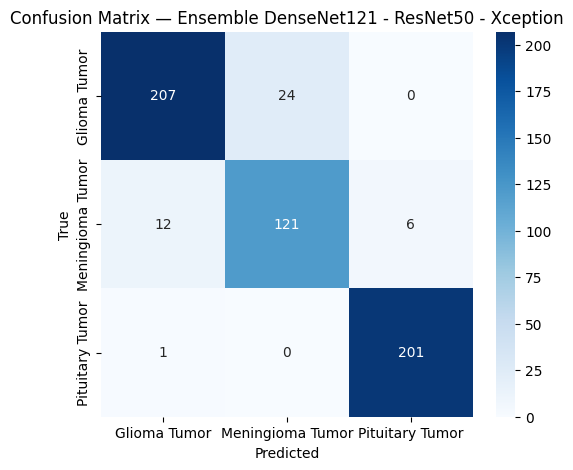

Fold: 4
Found 628 files belonging to 3 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 733ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      1.00      0.99       325
Meningioma Tumor       0.96      0.81      0.88       124
 Pituitary Tumor       0.91      0.97      0.94       179

        accuracy                           0.95       628
       macro avg       0.95      0.92      0.93       628
    weighted avg       0.95      0.95      0.95       628



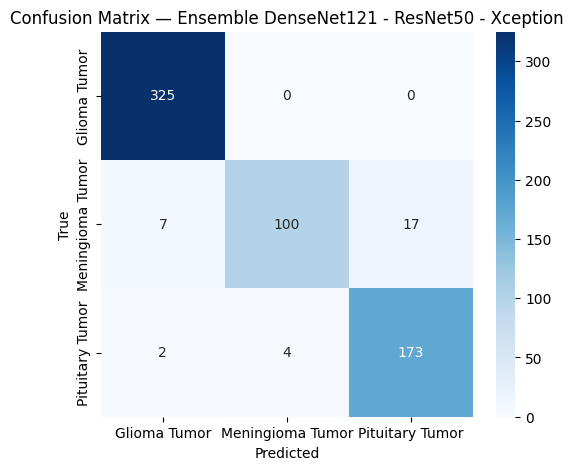

Fold: 5
Found 643 files belonging to 3 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 650ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 206ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.92      0.93       287
Meningioma Tumor       0.84      0.66      0.74       166
 Pituitary Tumor       0.81      0.99      0.90       190

        accuracy                           0.88       643
       macro avg       0.87      0.86      0.86       643
    weighted avg       0.88      0.88      0.87       643



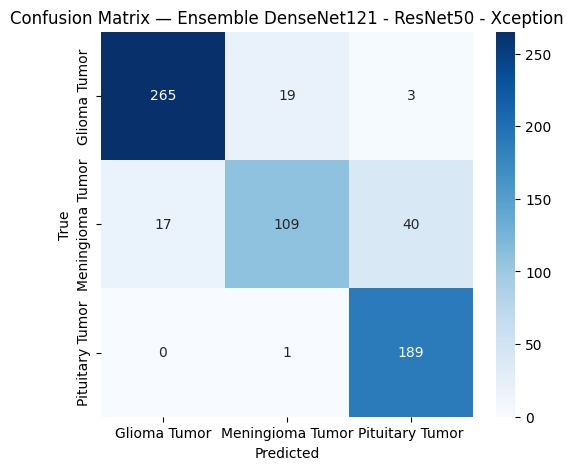

In [17]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k}')
    
    val_ds = get_validation_fold(fold_k)
    acc.append(test(val_ds, fold_k))

    del val_ds
    tf.keras.backend.clear_session()
    gc.collect()

In [18]:
print(f'Accuracy: {np.mean(acc) * 100:.2f}%')

Accuracy: 92.89%
